In [24]:
"""
This notebook demonstrates how to interact with the spam classification API.

Before running this notebook:
- Make sure the model is trained by running `src/main.py`
- Start the API locally by running `service/spam_classification_service.py`
"""

'\nThis notebook demonstrates how to interact with the spam classification API.\n\nBefore running this notebook:\n- Make sure the model is trained by running `src/main.py`\n- Start the API locally by running `service/spam_classification_service.py`\n'

In [25]:
import requests
import pandas as pd
from tqdm import tqdm

tqdm.pandas()

In [26]:
API_URL = "http://127.0.0.1:5000/predict"

# API Base usage

In [27]:
spam_example = "Don't miss our new AMAZING FEATURE by entering your credit card data!"
ham_example = "Dear Hiring Manager, Please find attached my application. Sincerely, Me."

In [28]:
response = requests.get(API_URL, params={"text": spam_example})
response.json()

{'cleaned_text': "Don't miss our new AMAZING FEATURE by entering your credit card data!",
 'confidence': 0.74,
 'prediction': 'spam',
 'text': "Don't miss our new AMAZING FEATURE by entering your credit card data!",
 'timestamp': '2026-05-04T18:57:30.469566'}

In [29]:
response = requests.get(API_URL, params={"text": ham_example})
response.json()

{'cleaned_text': 'Dear Hiring Manager, Please find attached my application. Sincerely, Me.',
 'confidence': 0.82,
 'prediction': 'ham',
 'text': 'Dear Hiring Manager, Please find attached my application. Sincerely, Me.',
 'timestamp': '2026-05-04T18:57:30.684682'}

# API on external dataset

In [30]:
"""
To run this part, download an additional dataset from Kaggle:
https://www.kaggle.com/datasets/ssssws/spam-email-detection-dataset-clean-and-ml-ready

Store it in `data/spam_email_dataset.csv`.

We will use this dataset as an unlabeled dataset and annotate it using the trained model via the API.
"""

'\nTo run this part, download an additional dataset from Kaggle:\nhttps://www.kaggle.com/datasets/ssssws/spam-email-detection-dataset-clean-and-ml-ready\n\nStore it in `data/spam_email_dataset.csv`.\n\nWe will use this dataset as an unlabeled dataset and annotate it using the trained model via the API.\n'

In [31]:
df_to_annotate = pd.read_csv("../data/spam_email_dataset.csv")
df_to_annotate["text_full"] = df_to_annotate.apply(lambda x: x["subject"] + " - " + x["email_text"], axis=1)
df_to_annotate["original_label"] = df_to_annotate["label"].apply(lambda x: "ham" if x== 0 else "spam")
df_to_annotate.set_index("email_id", inplace=True)
df_to_annotate = df_to_annotate[["text_full", "original_label"]]

In [32]:
df_to_annotate.head(10)

,text_full,original_label
email_id,,
0,Weekly Report - budget review - Statement our ...,ham
1,Project Update - team sync - President series ...,ham
2,🔥WIN BIG NOW!! - win free urgent offer limited...,spam
3,🔥WIN BIG NOW!! - guarantee click now cash offe...,spam
4,Meeting Reminder - team sync - Significant pro...,ham
5,Schedule Confirmation - project update - Exact...,ham
6,Weekly Report - budget review - Major east wri...,ham
7,You are selected!!! - win limited win offer cl...,spam
8,Meeting Reminder - team sync - Organization ea...,ham


In [82]:
def query_api(text):
    response = requests.get(API_URL, params={"text": text}).json()
    return response

In [ ]:
df_to_annotate["api_response"] = df_to_annotate["text_full"].progress_apply(query_api)

 72%|███████▏  | 7239/10000 [01:06<00:30, 90.37it/s] 

In [65]:
df_to_annotate["prediction"] = df_to_annotate["api_response"].apply(lambda x: x["prediction"])
df_to_annotate["confidence"] = df_to_annotate["api_response"].apply(lambda x: x["confidence"])
df_to_annotate["cleaned_text"] = df_to_annotate["api_response"].apply(lambda x: x["cleaned_text"])
df_to_annotate["timestamp"] = df_to_annotate["api_response"].apply(lambda x: pd.to_datetime(x["timestamp"]))

In [66]:
df_to_annotate["timestamp"][0]

Timestamp('2026-05-04 18:57:33.259158')

In [67]:
df_to_annotate.head(10)

,text_full,original_label,api_response,prediction,confidence,cleaned_text,timestamp
email_id,,,,,,,
0,Weekly Report - budget review - Statement our ...,ham,{'cleaned_text': 'Weekly Report - budget revie...,spam,0.79,Weekly Report - budget review - Statement our ...,2026-05-04 18:57:33.259158
1,Project Update - team sync - President series ...,ham,{'cleaned_text': 'Project Update - team sync -...,ham,0.75,Project Update - team sync - President series ...,2026-05-04 18:57:33.268789
2,🔥WIN BIG NOW!! - win free urgent offer limited...,spam,{'cleaned_text': '🔥WIN BIG NOW!! - win free ur...,spam,0.85,🔥WIN BIG NOW!! - win free urgent offer limited...,2026-05-04 18:57:33.279398
3,🔥WIN BIG NOW!! - guarantee click now cash offe...,spam,{'cleaned_text': '🔥WIN BIG NOW!! - guarantee c...,spam,0.94,🔥WIN BIG NOW!! - guarantee click now cash offe...,2026-05-04 18:57:33.289320
4,Meeting Reminder - team sync - Significant pro...,ham,{'cleaned_text': 'Meeting Reminder - team sync...,ham,0.60,Meeting Reminder - team sync - Significant pro...,2026-05-04 18:57:33.298247
5,Schedule Confirmation - project update - Exact...,ham,{'cleaned_text': 'Schedule Confirmation - proj...,ham,0.76,Schedule Confirmation - project update - Exact...,2026-05-04 18:57:33.305971
6,Weekly Report - budget review - Major east wri...,ham,{'cleaned_text': 'Weekly Report - budget revie...,spam,0.52,Weekly Report - budget review - Major east wri...,2026-05-04 18:57:33.313458
7,You are selected!!! - win limited win offer cl...,spam,{'cleaned_text': 'You are selected!!! - win li...,spam,0.96,You are selected!!! - win limited win offer cl...,2026-05-04 18:57:33.322405
8,Meeting Reminder - team sync - Organization ea...,ham,{'cleaned_text': 'Meeting Reminder - team sync...,ham,0.85,Meeting Reminder - team sync - Organization ea...,2026-05-04 18:57:33.329338


# Bonus

In [68]:
"""
As the dataset for we used for the example is actually annotated, let's see how our model in doing on that new dataset !
"""

"\nAs the dataset for we used for the example is actually annotated, let's see how our model in doing on that new dataset !\n"

In [69]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

In [70]:
y_true = df_to_annotate["original_label"]
y_pred = df_to_annotate["prediction"]

In [71]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

         ham       1.00      0.82      0.90      6005
        spam       0.79      1.00      0.88      3995

    accuracy                           0.89     10000
   macro avg       0.89      0.91      0.89     10000
weighted avg       0.91      0.89      0.89     10000



In [72]:
matrix = confusion_matrix(y_true, y_pred, labels=["ham", "spam"])

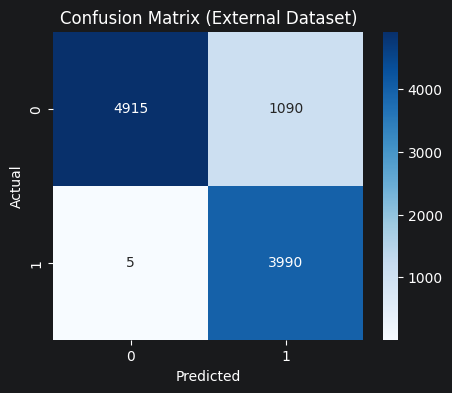

In [73]:
plt.figure(figsize=(5,4))
sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (External Dataset)")
plt.show()

In [74]:
df_to_annotate

,text_full,original_label,api_response,prediction,confidence,cleaned_text,timestamp
email_id,,,,,,,
0,Weekly Report - budget review - Statement our ...,ham,{'cleaned_text': 'Weekly Report - budget revie...,spam,0.79,Weekly Report - budget review - Statement our ...,2026-05-04 18:57:33.259158
1,Project Update - team sync - President series ...,ham,{'cleaned_text': 'Project Update - team sync -...,ham,0.75,Project Update - team sync - President series ...,2026-05-04 18:57:33.268789
2,🔥WIN BIG NOW!! - win free urgent offer limited...,spam,{'cleaned_text': '🔥WIN BIG NOW!! - win free ur...,spam,0.85,🔥WIN BIG NOW!! - win free urgent offer limited...,2026-05-04 18:57:33.279398
3,🔥WIN BIG NOW!! - guarantee click now cash offe...,spam,{'cleaned_text': '🔥WIN BIG NOW!! - guarantee c...,spam,0.94,🔥WIN BIG NOW!! - guarantee click now cash offe...,2026-05-04 18:57:33.289320
4,Meeting Reminder - team sync - Significant pro...,ham,{'cleaned_text': 'Meeting Reminder - team sync...,ham,0.60,Meeting Reminder - team sync - Significant pro...,2026-05-04 18:57:33.298247
...,...,...,...,...,...,...,...
9995,🔥WIN BIG NOW!! - free win cash win guarantee u...,spam,{'cleaned_text': '🔥WIN BIG NOW!! - free win ca...,spam,0.92,🔥WIN BIG NOW!! - free win cash win guarantee u...,2026-05-04 18:59:03.348866
9996,You are selected!!! - click now free guarantee...,spam,{'cleaned_text': 'You are selected!!! - click ...,spam,0.93,You are selected!!! - click now free guarantee...,2026-05-04 18:59:03.357291
9997,You are selected!!! - offer cash win limited c...,spam,{'cleaned_text': 'You are selected!!! - offer ...,spam,0.92,You are selected!!! - offer cash win limited c...,2026-05-04 18:59:03.365137


In [75]:
errors = df_to_annotate[df_to_annotate["original_label"] != df_to_annotate["prediction"]]

In [76]:
false_ham = errors[errors["prediction"] == "spam"]
false_ham.head(10)

,text_full,original_label,api_response,prediction,confidence,cleaned_text,timestamp
email_id,,,,,,,
0,Weekly Report - budget review - Statement our ...,ham,{'cleaned_text': 'Weekly Report - budget revie...,spam,0.79,Weekly Report - budget review - Statement our ...,2026-05-04 18:57:33.259158
6,Weekly Report - budget review - Major east wri...,ham,{'cleaned_text': 'Weekly Report - budget revie...,spam,0.52,Weekly Report - budget review - Major east wri...,2026-05-04 18:57:33.313458
16,Weekly Report - report - Account spring anythi...,ham,{'cleaned_text': 'Weekly Report - report - Acc...,spam,0.53,Weekly Report - report - Account spring anythi...,2026-05-04 18:57:33.381561
19,Weekly Report - team sync - May measure such b...,ham,{'cleaned_text': 'Weekly Report - team sync - ...,spam,0.53,Weekly Report - team sync - May measure such b...,2026-05-04 18:57:33.399085
33,Project Update - report - Doctor wonder size g...,ham,{'cleaned_text': 'Project Update - report - Do...,spam,0.78,Project Update - report - Doctor wonder size g...,2026-05-04 18:57:33.496255
35,Weekly Report - team sync - Kind project hair ...,ham,{'cleaned_text': 'Weekly Report - team sync - ...,spam,0.54,Weekly Report - team sync - Kind project hair ...,2026-05-04 18:57:33.515511
40,Schedule Confirmation - schedule - Whether ope...,ham,{'cleaned_text': 'Schedule Confirmation - sche...,spam,0.55,Schedule Confirmation - schedule - Whether ope...,2026-05-04 18:57:33.560805
47,Meeting Reminder - schedule - Car reduce too w...,ham,{'cleaned_text': 'Meeting Reminder - schedule ...,spam,0.55,Meeting Reminder - schedule - Car reduce too w...,2026-05-04 18:57:33.612236
60,Schedule Confirmation - project update - Fire ...,ham,{'cleaned_text': 'Schedule Confirmation - proj...,spam,0.71,Schedule Confirmation - project update - Fire ...,2026-05-04 18:57:33.696875


In [77]:
false_ham.iloc[0]["text_full"]

'Weekly Report - budget review - Statement our I claim world star. Myself a entire. Enough sport baby every wear economic daughter.'

In [78]:
false_spam = errors[errors["prediction"] == "ham"]
false_spam.head(10)

,text_full,original_label,api_response,prediction,confidence,cleaned_text,timestamp
email_id,,,,,,,
235,You are selected!!! - urgent cash urgent win o...,spam,{'cleaned_text': 'You are selected!!! - urgent...,ham,0.52,You are selected!!! - urgent cash urgent win o...,2026-05-04 18:57:35.090229
2817,Limited Offer!!! - urgent urgent cash cash fre...,spam,{'cleaned_text': 'Limited Offer!!! - urgent ur...,ham,0.53,Limited Offer!!! - urgent urgent cash cash fre...,2026-05-04 18:57:58.979814
4561,You are selected!!! - cash win offer offer cas...,spam,{'cleaned_text': 'You are selected!!! - cash w...,ham,0.60,You are selected!!! - cash win offer offer cas...,2026-05-04 18:58:16.378933
8528,Limited Offer!!! - urgent free free click now ...,spam,{'cleaned_text': 'Limited Offer!!! - urgent fr...,ham,0.57,Limited Offer!!! - urgent free free click now ...,2026-05-04 18:58:51.677344
9372,You are selected!!! - urgent guarantee free of...,spam,{'cleaned_text': 'You are selected!!! - urgent...,ham,0.51,You are selected!!! - urgent guarantee free of...,2026-05-04 18:58:58.715256


In [79]:
false_spam.iloc[0]["text_full"]

'You are selected!!! - urgent cash urgent win offer cash Hear herself unit challenge budget summer edge impact.'